# Step 6: Item recommendations via cosine similarity

This notebook compares the board's vibe vector (notebook 02) against every item's embedding (notebook 03) and ranks items by how visually/stylistically similar they are to the board -- no model inference needed here, just vector math on the cached embeddings.

## Load the cached embeddings

Both of these were saved to disk in earlier notebooks, so we load them directly instead of recomputing anything -- this is the whole point of caching. We use plain NumPy here rather than PyTorch, since this step is just array math with no model involved.

In [1]:
from pathlib import Path
import numpy as np

vibe_vector = np.load(Path("../data/embeddings/board_vibe_vector.npy"))
item_embeddings = np.load(Path("../data/embeddings/item_embeddings.npy"))
item_ids = np.load(Path("../data/embeddings/item_ids.npy"))

print("Vibe vector shape:", vibe_vector.shape)
print("Item embeddings shape:", item_embeddings.shape)
print("Item ids shape:", item_ids.shape)

Vibe vector shape: (512,)
Item embeddings shape: (44419, 512)
Item ids shape: (44419,)


## Cosine similarity, explained

Cosine similarity measures the *angle* between two vectors, ignoring their length. For two vectors `a` and `b`:

```
cosine_similarity(a, b) = (a . b) / (|a| * |b|)
```

- `a . b` (the **dot product**) multiplies the vectors element-by-element and sums the result. It grows when two vectors point in similar directions, and grows further if they're also long.
- Dividing by `|a| * |b|` (the product of their lengths/**norms**) cancels out the "long vectors give bigger dot products" effect, leaving a score that only reflects *direction*.
- The result ranges from -1 (opposite directions) to 1 (identical direction); 0 means unrelated (perpendicular).

This is the right tool here because embedding *length* isn't meaningful for FashionCLIP -- two images could point in nearly the same direction in the embedding space (same style) but differ in vector length for reasons that have nothing to do with style. We only care about direction: "does this item's embedding point the same way as the board's vibe?"

Recall the vibe vector was already L2-normalized in notebook 02 (length 1), but the item embeddings were **not** normalized in notebook 03 -- so we compute the full formula below rather than assuming both sides are unit length.

In [ ]:
# item_embeddings @ vibe_vector computes the dot product of the vibe vector against
# EVERY item's embedding in one vectorized matrix-vector multiply: (44419, 512) @ (512,) -> (44419,)
dot_products = item_embeddings @ vibe_vector

item_norms = np.linalg.norm(item_embeddings, axis=1)  # length of each item vector: (44419,)
vibe_norm = np.linalg.norm(vibe_vector)                # length of the vibe vector: a single number

cosine_similarities = dot_products / (item_norms * vibe_norm)

print("Similarities shape:", cosine_similarities.shape)
print("Min / max similarity:", cosine_similarities.min(), "/", cosine_similarities.max())

## Rank and take the top matches

`np.argsort` returns the *indices* that would sort an array smallest-to-largest. We sort the negated similarities so the result comes out largest-to-smallest, then take the first `TOP_K` indices -- the items whose embeddings point most closely in the same direction as the board's vibe.

In [ ]:
TOP_K = 15

top_indices = np.argsort(-cosine_similarities)[:TOP_K]
top_item_ids = item_ids[top_indices]
top_scores = cosine_similarities[top_indices]

for item_id, score in zip(top_item_ids, top_scores):
    print(f"id={item_id}  similarity={score:.4f}")

## Look up what these items actually are

IDs and similarity scores aren't very meaningful on their own -- let's join them back to `styles.csv` to see the actual product names, categories, and colors.

In [ ]:
import pandas as pd

dataset_root = Path.home() / ".cache/kagglehub/datasets/paramaggarwal/fashion-product-images-small/versions/1"
styles_csv = dataset_root / "styles.csv"

df = pd.read_csv(styles_csv, on_bad_lines="skip").set_index("id")

# .loc with a list preserves the given order, so this stays ranked best-to-worst
results = df.loc[top_item_ids, ["productDisplayName", "articleType", "baseColour", "usage"]].copy()
results["similarity"] = top_scores
results

## Visual sanity check

Numbers and category labels only tell you so much -- let's actually look at the recommended items next to the board's aesthetic, per the scope doc's Step 12 evaluation approach.

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

images_dir = dataset_root / "images"

fig, axes = plt.subplots(3, 5, figsize=(15, 10))
for ax, item_id, score in zip(axes.flat, top_item_ids, top_scores):
    img = Image.open(images_dir / f"{item_id}.jpg")
    ax.imshow(img)
    ax.set_title(f"{score:.3f}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [2]:
from pathlib import Path
import numpy as np

vibe_vector = np.load(Path("../data/embeddings/board_vibe_vector.npy"))
item_embeddings = np.load(Path("../data/embeddings/item_embeddings.npy"))
item_ids = np.load(Path("../data/embeddings/item_ids.npy"))

print("Vibe vector shape:", vibe_vector.shape)
print("Item embeddings shape:", item_embeddings.shape)
print("Item ids shape:", item_ids.shape)

Vibe vector shape: (512,)
Item embeddings shape: (44419, 512)
Item ids shape: (44419,)


In [3]:
dot_products = item_embeddings @ vibe_vector

item_norms = np.linalg.norm(item_embeddings, axis=1)
vibe_norm = np.linalg.norm(vibe_vector)

cosine_similarities = dot_products / (item_norms * vibe_norm)

print("Similarities shape:", cosine_similarities.shape)
print("Min / max similarity:", cosine_similarities.min(), "/", cosine_similarities.max())

Similarities shape: (44419,)
Min / max similarity: 0.12855335 / 0.71687233


In [4]:
TOP_K = 15

top_indices = np.argsort(-cosine_similarities)[:TOP_K]
top_item_ids = item_ids[top_indices]
top_scores = cosine_similarities[top_indices]

for item_id, score in zip(top_item_ids, top_scores):
    print(f"id={item_id}  similarity={score:.4f}")

id=5153  similarity=0.7169
id=6199  similarity=0.7138
id=57106  similarity=0.7121
id=6312  similarity=0.7118
id=57896  similarity=0.7104
id=44706  similarity=0.7098
id=57180  similarity=0.7006
id=57094  similarity=0.6986
id=6703  similarity=0.6908
id=50190  similarity=0.6861
id=6687  similarity=0.6858
id=54986  similarity=0.6848
id=6892  similarity=0.6829
id=5140  similarity=0.6821
id=6230  similarity=0.6815


In [5]:
import pandas as pd

dataset_root = Path.home() / ".cache/kagglehub/datasets/paramaggarwal/fashion-product-images-small/versions/1"
styles_csv = dataset_root / "styles.csv"

df = pd.read_csv(styles_csv, on_bad_lines="skip").set_index("id")

results = df.loc[top_item_ids, ["productDisplayName", "articleType", "baseColour", "usage"]].copy()
results["similarity"] = top_scores
results

,productDisplayName,articleType,baseColour,usage,similarity
id,,,,,
5153,Wrangler Women's Side Paisley White T-shirt,Tshirts,White,Casual,0.716872
6199,UCB Women's Basic Spaghetti White Top,Tops,White,Casual,0.713825
57106,Elle Women White Top,Tops,White,Casual,0.712087
6312,UCB Women's Basic Racerback White Top,Tops,White,Casual,0.711823
57896,Femella Women Off White Shorts,Shorts,Off White,Casual,0.710365
44706,Wills Lifestyle Women White Top,Tops,White,Casual,0.709850
57180,Elle Women Blue Denim Tunic,Tunics,Blue,Casual,0.700616
57094,Elle Women Greyish Blue Culottes,Shorts,Blue,Casual,0.698559
6703,UCB Women's Epaulettes On Sleeve White T-shirt,Tshirts,White,Casual,0.690811


Matplotlib is building the font cache; this may take a moment.


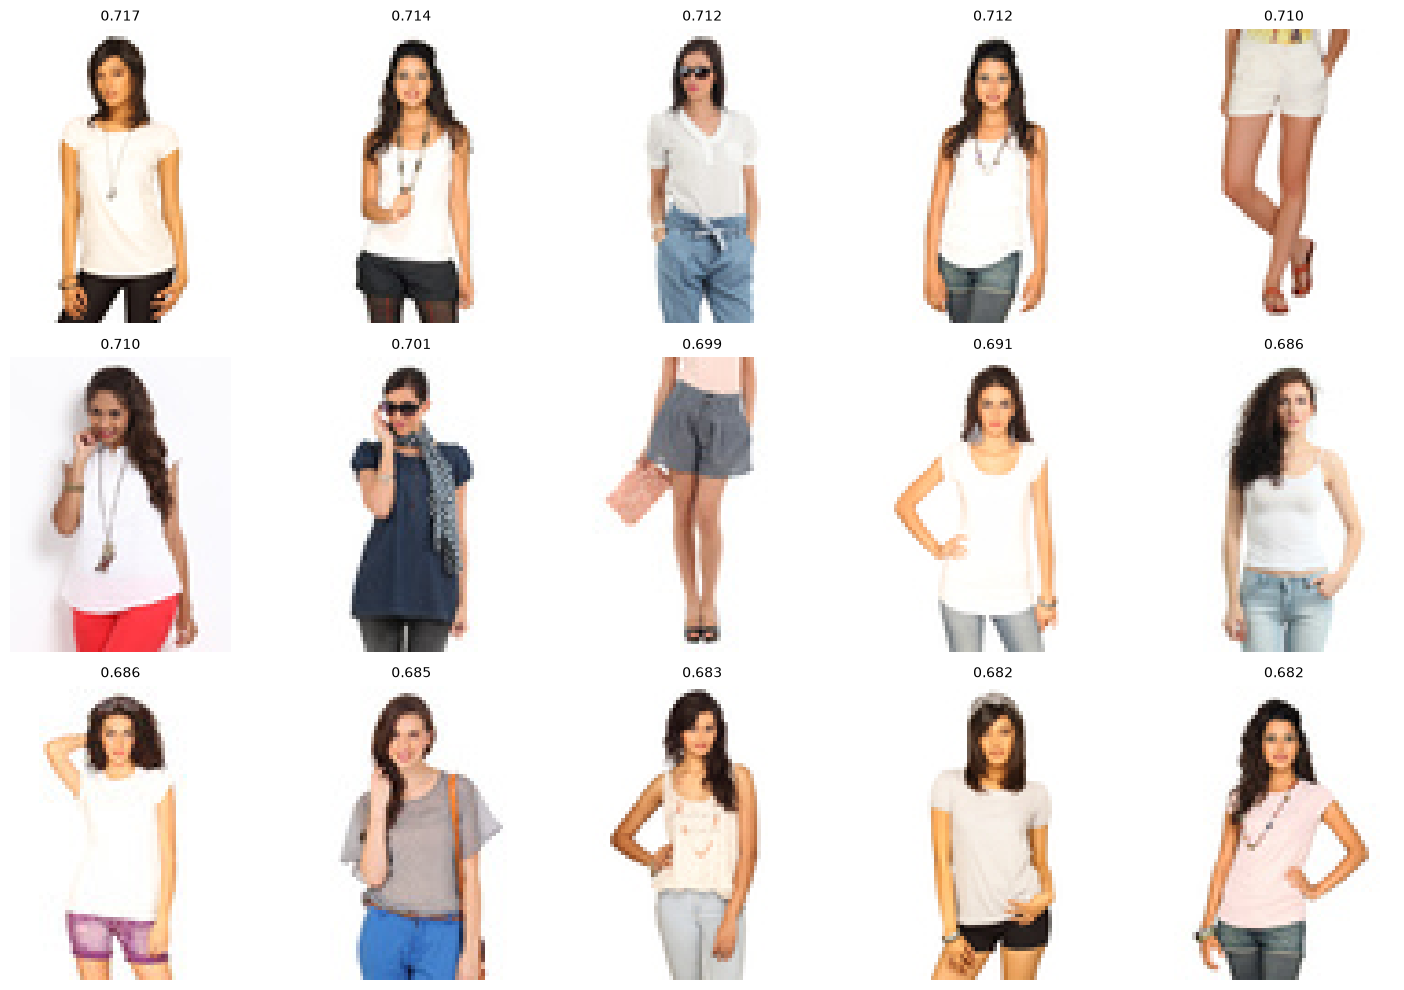

In [6]:
import matplotlib.pyplot as plt
from PIL import Image

images_dir = dataset_root / "images"

fig, axes = plt.subplots(3, 5, figsize=(15, 10))
for ax, item_id, score in zip(axes.flat, top_item_ids, top_scores):
    img = Image.open(images_dir / f"{item_id}.jpg")
    ax.imshow(img)
    ax.set_title(f"{score:.3f}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()